<a href="https://colab.research.google.com/github/ARNAVKS/Fraud-Detection/blob/main/Fraud_Detection_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Dataset

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
  0% 0.00/66.0M [00:00<?, ?B/s]
100% 66.0M/66.0M [00:00<00:00, 1.31GB/s]


In [3]:
from zipfile import ZipFile
path="/content/creditcardfraud.zip"
with ZipFile(path,'r') as data:
  data.extractall()

Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score,roc_auc_score,auc,roc_curve,confusion_matrix,silhouette_score

Reading the Dataset

In [5]:
df=pd.read_csv('creditcard.csv')

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape

(284807, 31)

In [8]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
284802,False
284803,False
284804,False
284805,False


As you can see class is highly imbalance so we have to perform oversampling or undersampling method later

In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


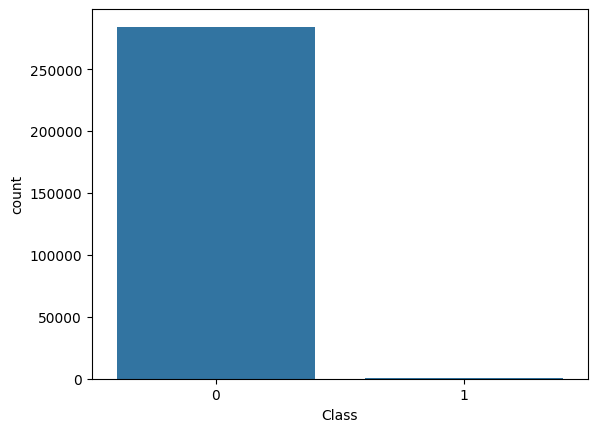

In [10]:
sns.countplot(x='Class',data=df)
plt.show()

In [11]:
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


Checking for the null values

In [12]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Splitting the data into features and target

In [13]:
X=df.drop(columns='Class',axis=1)
y=df['Class']

In [14]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


All data except the Time and Amount column are already scaled so scaling them

In [15]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X[['Time','Amount']]=sc.fit_transform(X[['Time','Amount']])

You can see it is a high dimensional data, so reducing the columns using PCA keeping in mind that we have to retain more than 95% of the variance

In [16]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.95,random_state=42)
X_pca=pca.fit_transform(X)

In [17]:
X_pca.shape

(284807, 23)

***

Splitting the features and target into a training and testing data, into $80:20$ ratio with stratifying y as y has a huge imbalanced class

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42,stratify=y)

In [19]:
y_train.value_counts()

,count
Class,
0,227451
1,394


In [20]:
y_test.value_counts()

,count
Class,
0,56864
1,98


***

Performing oversampling on training data only and keeping testing data as it is.

In [21]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
rus=RandomUnderSampler(random_state=42)
Xtrain_s,ytrain_s=smote.fit_resample(X_train,y_train)
Xtrain_rus,ytrain_rus=rus.fit_resample(X_train,y_train)

In [22]:
ytrain_s.value_counts()

,count
Class,
0,227451
1,227451


In [23]:
ytrain_rus.value_counts()

,count
Class,
0,394
1,394


***

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Training Random forest model using the training data

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xtrain_s, ytrain_s)
y_pred_rf = rf.predict(X_test)

In [ ]:
rf_ = RandomForestClassifier(n_estimators=100, random_state=42)
rf_.fit(Xtrain_rus, ytrain_rus)
y_pred_rf_rus = rf_.predict(X_test)

***

Evaluating the model using the testing data



*   Oversampled training data model


In [ ]:
print("Random Forest Report using oversampling:\n", classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9623409560081772


In [ ]:
f1_score(y_test, y_pred_rf)

0.8290155440414507

* Undersampled training data model

In [ ]:
print("Random Forest Report using undersampling:\n", classification_report(y_test, y_pred_rf_rus))
print("ROC-AUC:", roc_auc_score(y_test, rf_.predict_proba(X_test)[:,1]))

Random Forest Report using undersampling:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9708636180274023


In [ ]:
f1_score(y_test, y_pred_rf_rus)

0.08383791336748952

As you can see model trained on a oversampled training data predicts the unchanged testing data nicely than the model trained on a undersampled training data

In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[56849,    15],
       [   18,    80]])

In [ ]:
confusion_matrix(y_test, y_pred_rf_rus)

array([[54905,  1959],
       [    8,    90]])

So we can conclude that Oversampling technique works well as the minority class number is too low as after undersampling the dataset became too small to train

***

Plotting ROC-AUC graph

In [ ]:
y_pred_prob=rf.predict_proba(X_test)[:,1]

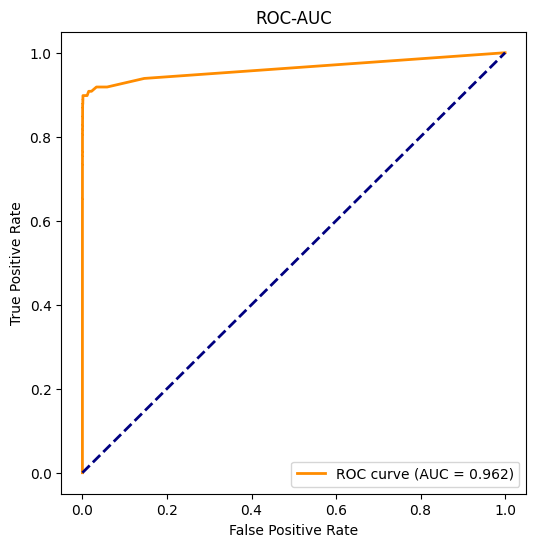

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC')
plt.legend(loc="lower right")
plt.show()

***

Now doing Unsupervised learning on PCA data

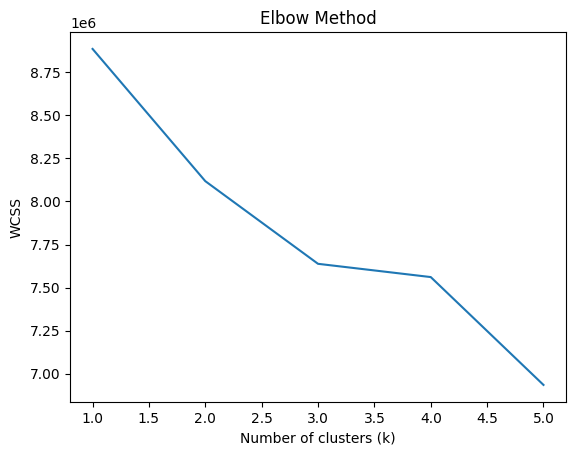

In [24]:
wcss = []
for k in range(1,6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    wcss.append(km.inertia_)

plt.plot(range(1,6),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()

By elbow method, i choose k=2

In [ ]:
model=KMeans(n_clusters=2)
model.fit(X_pca)

KMeans(n_clusters=2)

Calculating Silhouette Score

In [ ]:
clusters = model.fit_predict(X_pca)
sil_score = silhouette_score(X_pca, clusters)

In [ ]:
sil_score

np.float64(0.10974139327994745)

As we can see even after choosing ideal k value from elbow method we got the low Silhouette Score which tells that the fraudulent data is very scattered and can't be put up as a cluster

In [ ]:
X_pca.shape,y.shape

((284807, 23), (284807,))

Now for visualizing the clusters for the above, i reduced the columns into 2 features column and performs clustering with 2 clustering

In [ ]:
pca1=PCA(n_components=2)
x_pca1=pca1.fit_transform(X_pca)

In [ ]:
x_pca1

array([[-1.57167813,  0.67557198],
       [ 1.0862128 ,  0.28267337],
       [-2.05341145, -1.07763353],
       ...,
       [ 1.99848857, -1.21642389],
       [ 0.04075866,  0.60471835],
       [-0.55050189, -0.40173308]])

Look at how this cluster were made and data is too scattered


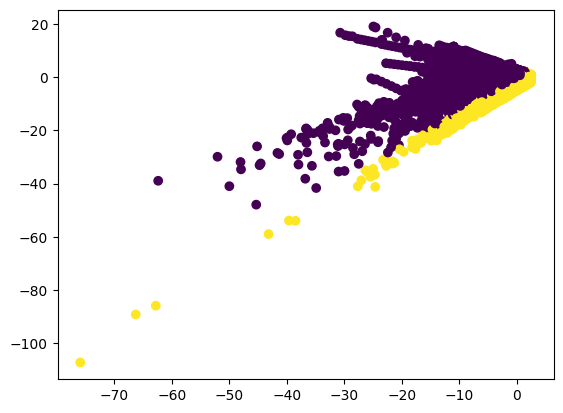

In [ ]:
m=KMeans(n_clusters=2)
pca1_pred=m.fit_predict(x_pca1)
plt.scatter(x_pca1[:,0],x_pca1[:,1],c=pca1_pred)
plt.show()

Now performing clustering on the oversampled or balanced data

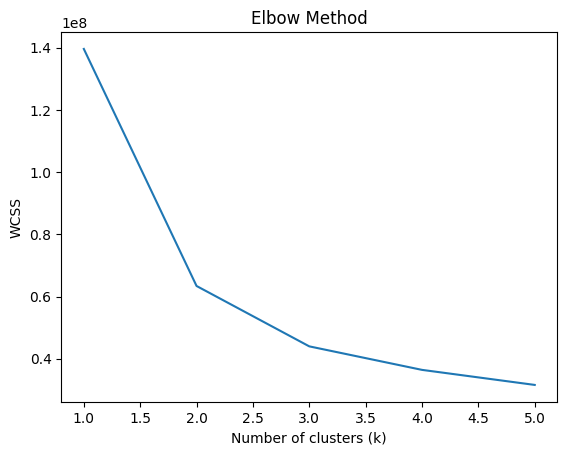

In [25]:
wcss = []
for k in range(1,6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(Xtrain_s)
    wcss.append(km.inertia_)

plt.plot(range(1,6),wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [26]:
model=KMeans(n_clusters=2)
model.fit(Xtrain_s)

KMeans(n_clusters=2)

Cluster for training data

In [27]:
train_clus = model.predict(Xtrain_s)

Silhouette Score for training data

In [28]:
silhouette_score(Xtrain_s,train_clus)

np.float64(0.6393370826817363)

Cluster on testing data

In [29]:
test_clus = model.predict(X_test)

Silhouette Score for testing data

In [30]:
silhouette_score(X_test,test_clus)

np.float64(0.8363550641808911)

See how Silhouette Score improved from 0.11 to 0.63 by fitting with synthetic oversampled data and on testing original imbalance data it give 0.83 Score which is impressive